In [1]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['date_added'] = df['date_added'].ffill()

In [5]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

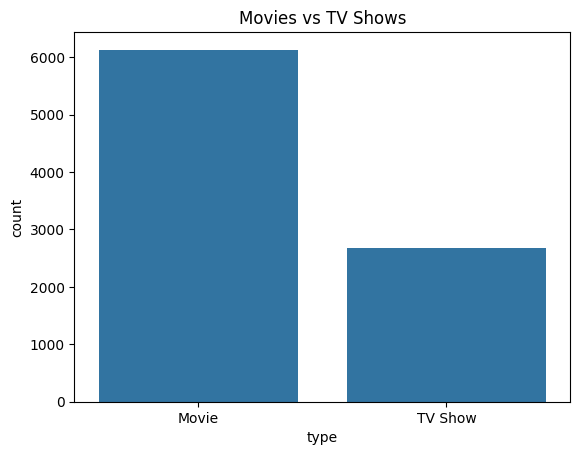

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

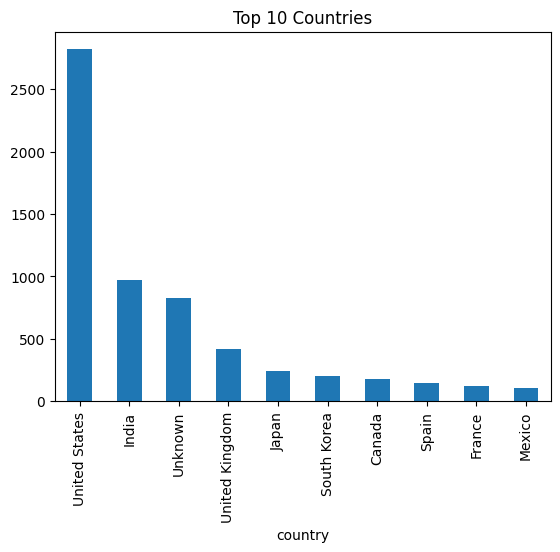

In [7]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [10]:
df['date_added'] = df['date_added'].ffill()

In [11]:
df['date_added'].dtype

dtype('<M8[ns]')

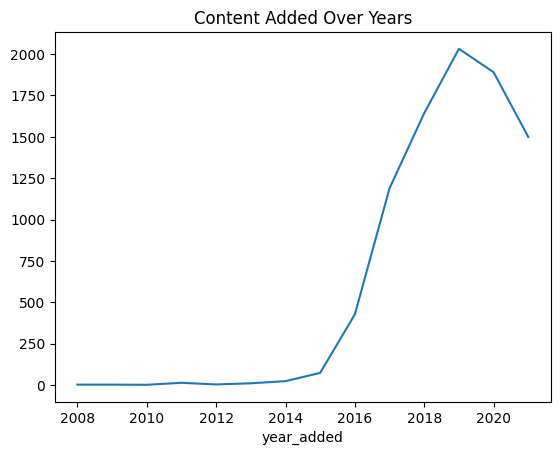

In [12]:
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added Over Years")
plt.show()

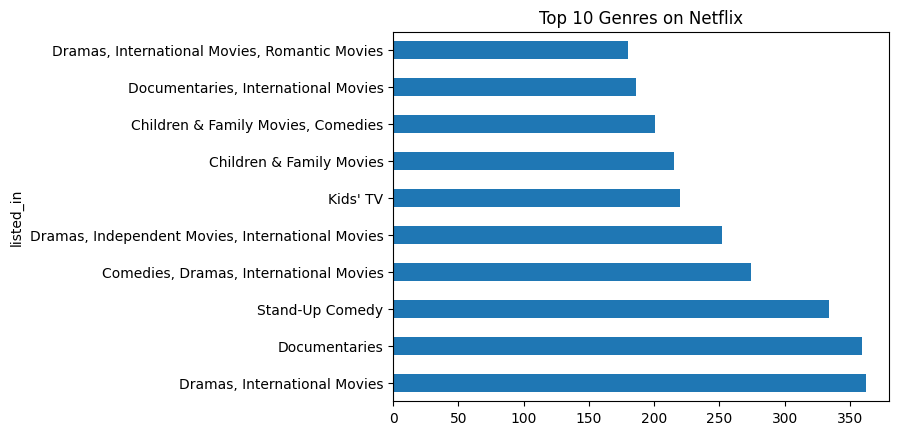

In [13]:
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Genres on Netflix")
plt.show()

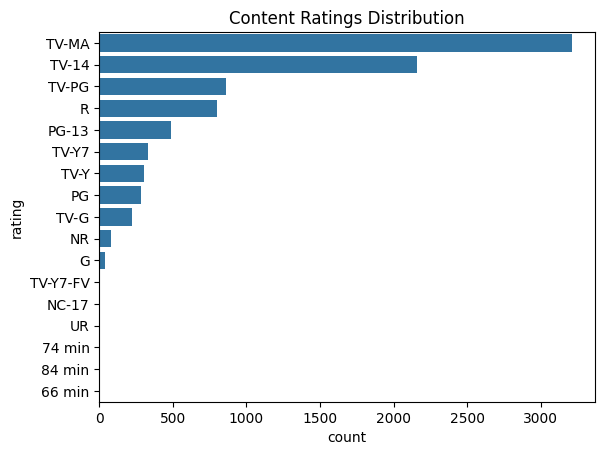

In [14]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

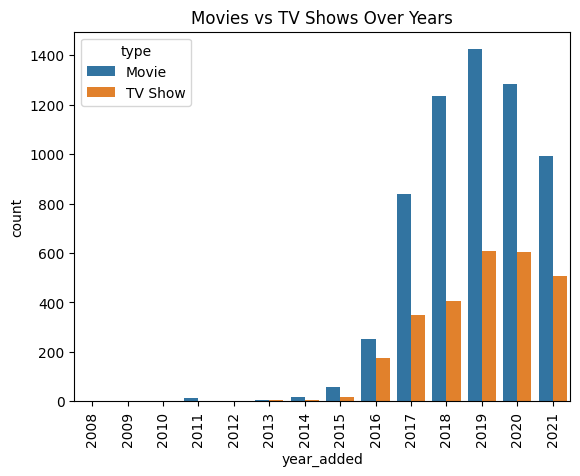

In [15]:
sns.countplot(x='year_added', hue='type', data=df)
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows Over Years")
plt.show()

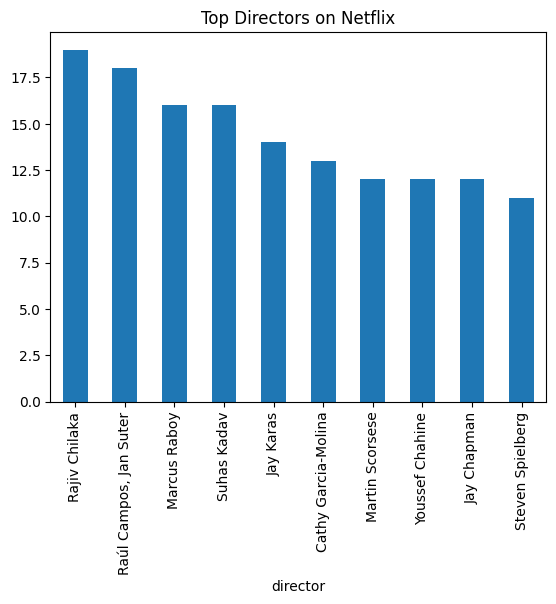

In [16]:
df[df['director'] != 'Unknown']['director'].value_counts().head(10).plot(kind='bar')
plt.title("Top Directors on Netflix")
plt.show()

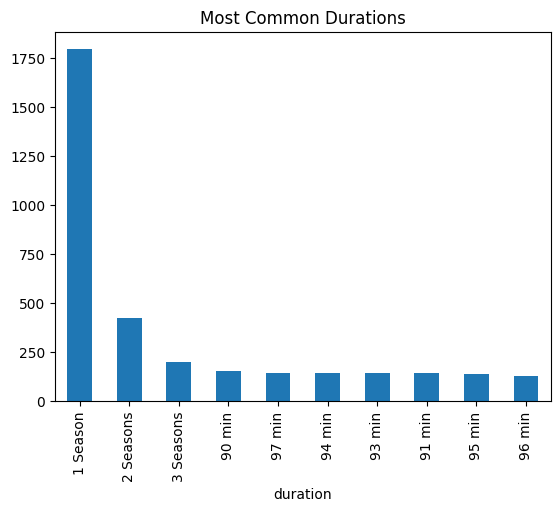

In [17]:
df['duration'].value_counts().head(10).plot(kind='bar')
plt.title("Most Common Durations")
plt.show()